<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-HUYTRUONG/AIO/blob/aio/M4-Foundation-DL/Optimization/M04W01/Linear%20Regression/gradient_descent_optimizer_1d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple,List
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True  # <--- BẮT BUỘC TRÊN COLAB / JUPYTER
)

logger = logging.getLogger(__name__)

logger.info("Test logger thành công trên Colab!")
logger.debug("Test debug log!")

2026-10-02 14:38:58,350 - INFO - Test logger thành công trên Colab!


In [7]:
class GradientDescentOptimizer:
  """
  Trình tối ưu hóa Gradient Descent 1 chiều

  Attributes:
    objective_func (Callable[[float], float]): Hàm mục tiêu f(x).
    derivative_func (Callable[[float], float]): Đạo hàm f'(x).
    learning_rate (float): Tốc độ học
    num_steps (int): Số bước lặp tối đa
  """

  def __init__(
      self,
      objective_func: Callable[[float], float],
      derivative_func: Callable[[float], float],
      learning_rate: float = 0.1,
      num_steps: int = 10
  ) -> None:

    if learning_rate <= 0:
      raise ValueError("Tốc độ học phải lớn hơn 0")

    if num_steps <= 0:
      raise ValueError("Số bước lặp phải lớn hơn 0")

    self.objective_func = objective_func
    self.derivative_func = derivative_func
    self.learning_rate = learning_rate
    self.num_steps = num_steps

    # Lưu lịch sử quá trình tối ưu để vẽ đồ thị
    self.x_history: List[float] = []
    self.loss_history: List[float] = []

  def optimize(self, initial_x: float) -> float:
    """
    Thực hiện quá trình tối ưu hóa từ initial_x

    Args:
      initial_x (float): Giá trị ban đầu cho x

    Returns:
      float: Giá trị tối ưu cho x sau quá trình tối ưu hóa
    """

    x = float(initial_x)
    self.x_history = [x]
    self.loss_history = [self.objective_func(x)]

    logger.info(f"Khởi tạo x = {x:.4f}, f(x) = {self.objective_func(x):.4f}")

    for step in range(self.num_steps):
      # Tính đạo hàm tại x
      dx = self.derivative_func(x)

      # Cập nhật tham số
      x_next = x - self.learning_rate * dx
      loss = self.objective_func(x_next)
      logger.info(f"Bước {step:03d} | x = {x:.6f} | Loss = {loss:.6f} | dx = {dx:.6f}")

      x = x_next

      self.x_history.append(x)
      self.loss_history.append(loss)


    logger.info(f"Hoàn thành! x_opt = {x:.6f}, f(x_opt) = {self.objective_func(x):.6f}")
    return x

  def plot_optimization_path(
        self, x_range: Tuple[float, float] = (-100, 100)
    ) -> None:
        """Vẽ đồ thị minh họa quá trình di chuyển của x_opt trên hàm mục tiêu."""
        if not self.x_history:
            raise RuntimeError("Vui lòng chạy .optimize() trước khi vẽ đồ thị!")

        # 1. Khởi tạo đường cong đường f(x)
        x_vals = np.linspace(x_range[0], x_range[1], 1000)
        y_vals = [self.objective_func(x_i) for x_i in x_vals]

        plt.figure(figsize=(10, 6))

        # 2. Vẽ đường hàm mục tiêu f(x)
        plt.plot(x_vals, y_vals, "b-", label="f(x)", alpha=0.6)

        # 3. Vẽ các điểm x qua từng bước lặp
        plt.plot(
            self.x_history,
            self.loss_history,
            "ro--",
            linewidth=1.5,
            markersize=6,
            label="Đường di chuyển của x (Trajectory)",
        )

        # 4. Đánh dấu điểm khởi tạo và điểm tối ưu x_opt
        plt.scatter(
            self.x_history[0],
            self.loss_history[0],
            color="green",
            s=120,
            zorder=5,
            label=f"Start (x_0 = {self.x_history[0]:.2f})",
        )
        plt.scatter(
            self.x_history[-1],
            self.loss_history[-1],
            color="gold",
            edgecolors="black",
            s=150,
            zorder=5,
            label=f"Optimum (x_opt = {self.x_history[-1]:.3f})",
        )

        # 5. Định dạng đồ thị
        plt.title(
            f"Quá trình Gradient Descent (lr={self.learning_rate}, steps={self.num_steps})",
            fontsize=13,
            fontweight="bold",
        )
        plt.xlabel("x", fontsize=11)
        plt.ylabel("f(x)", fontsize=11)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="upper center", fontsize=10)
        plt.tight_layout()
        plt.show()

2026-10-02 14:33:19,124 - INFO - Khởi tạo x = 54.7912, f(x) = 3002.0767
2026-10-02 14:33:19,126 - INFO - Bước 000 | x = 54.791210 | Loss = 1921.329063 | dx = 109.582419
2026-10-02 14:33:19,127 - INFO - Bước 001 | x = 43.832968 | Loss = 1229.650601 | dx = 87.665936
2026-10-02 14:33:19,129 - INFO - Bước 002 | x = 35.066374 | Loss = 786.976384 | dx = 70.132748
2026-10-02 14:33:19,129 - INFO - Bước 003 | x = 28.053099 | Loss = 503.664886 | dx = 56.106199
2026-10-02 14:33:19,130 - INFO - Bước 004 | x = 22.442479 | Loss = 322.345527 | dx = 44.884959
2026-10-02 14:33:19,132 - INFO - Bước 005 | x = 17.953984 | Loss = 206.301137 | dx = 35.907967
2026-10-02 14:33:19,133 - INFO - Bước 006 | x = 14.363187 | Loss = 132.032728 | dx = 28.726374
2026-10-02 14:33:19,134 - INFO - Bước 007 | x = 11.490550 | Loss = 84.500946 | dx = 22.981099
2026-10-02 14:33:19,134 - INFO - Bước 008 | x = 9.192440 | Loss = 54.080605 | dx = 18.384879
2026-10-02 14:33:19,135 - INFO - Bước 009 | x = 7.353952 | Loss = 34.6115

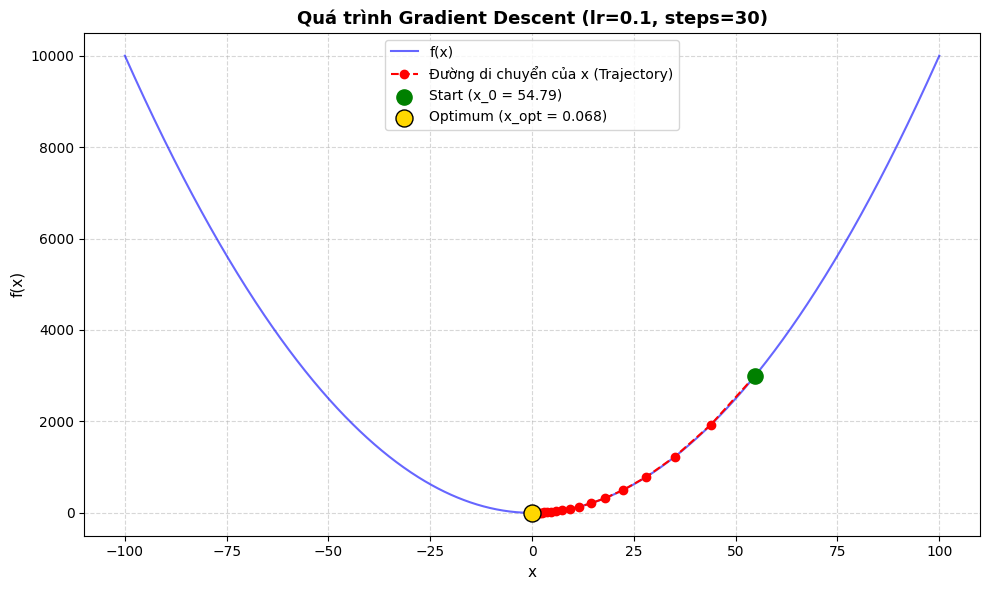

In [5]:
# Hàm mục tiêu f(x) = x^2
def target_function(x:float) ->float:
  return x ** 2

# Đạo hàm f'(x) = 2x
def target_derivative(x:float) ->float:
  return 2 * x

rng = np.random.default_rng(seed=42)
x = rng.uniform(-100.0,100.0)
lr = 0.1
num_steps = 30

optimizer = GradientDescentOptimizer(
    objective_func=target_function,
    derivative_func=target_derivative,
    learning_rate=lr,
    num_steps=num_steps
)

best_x = optimizer.optimize(initial_x=x)
optimizer.plot_optimization_path(x_range=(-100, 100))